In [1]:
import pandas as pd

results = pd.read_csv("../results_experiments/protbert_experiment_results_no_plants.csv")
results["Model"] = "ProtBERT"
results.head()

,Model type,Trial,Fold,F1_macro,Model
0,TL,15,0,0.857327,ProtBERT
1,No TL,15,0,0.830893,ProtBERT
2,TL,15,1,0.848276,ProtBERT
3,No TL,15,1,0.813135,ProtBERT
4,TL,15,2,0.876954,ProtBERT


In [2]:
results_all = results

In [3]:
import pandas as pd

results = pd.read_csv("../results_experiments/results_esm1b_no_plants.csv")
results["Model"] = "ESM-1b"
results.head()

,Model type,Trial,Fold,F1_macro,Model
0,TL,18,0,0.860866,ESM-1b
1,No TL,18,0,0.787485,ESM-1b
2,TL,18,1,0.862871,ESM-1b
3,No TL,18,1,0.786621,ESM-1b
4,TL,18,2,0.811398,ESM-1b


In [4]:
results_all = pd.concat([results_all, results])
results_all

,Model type,Trial,Fold,F1_macro,Model
0,TL,15,0,0.857327,ProtBERT
1,No TL,15,0,0.830893,ProtBERT
2,TL,15,1,0.848276,ProtBERT
3,No TL,15,1,0.813135,ProtBERT
4,TL,15,2,0.876954,ProtBERT
...,...,...,...,...,...
95,No TL,27,2,0.811710,ESM-1b
96,TL,27,3,0.866297,ESM-1b
97,No TL,27,3,0.791265,ESM-1b
98,TL,27,4,0.819054,ESM-1b


In [5]:
import pandas as pd

results = pd.read_csv("../results_experiments/results_esm2_3b_no_plants.csv")
results.head()

,Model type,Trial,Fold,F1_macro
0,TL,11,0,0.823719
1,No TL,11,0,0.823128
2,TL,11,1,0.837254
3,No TL,11,1,0.802885
4,TL,11,2,0.856315


In [6]:
results["Model"] = "ESM-2 3B"

In [7]:
results_all = pd.concat([results_all, results])

In [8]:
results_all

,Model type,Trial,Fold,F1_macro,Model
0,TL,15,0,0.857327,ProtBERT
1,No TL,15,0,0.830893,ProtBERT
2,TL,15,1,0.848276,ProtBERT
3,No TL,15,1,0.813135,ProtBERT
4,TL,15,2,0.876954,ProtBERT
...,...,...,...,...,...
95,No TL,20,2,0.844408,ESM-2 3B
96,TL,20,3,0.812025,ESM-2 3B
97,No TL,20,3,0.828120,ESM-2 3B
98,TL,20,4,0.868564,ESM-2 3B


/tmp/ipykernel_4094470/3653968223.py:13: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(x='Model', y='F1_macro', hue='Model type', data=results_all,
/tmp/ipykernel_4094470/3653968223.py:21: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(x='Model', y='F1_macro', hue='Model type', data=results_all,


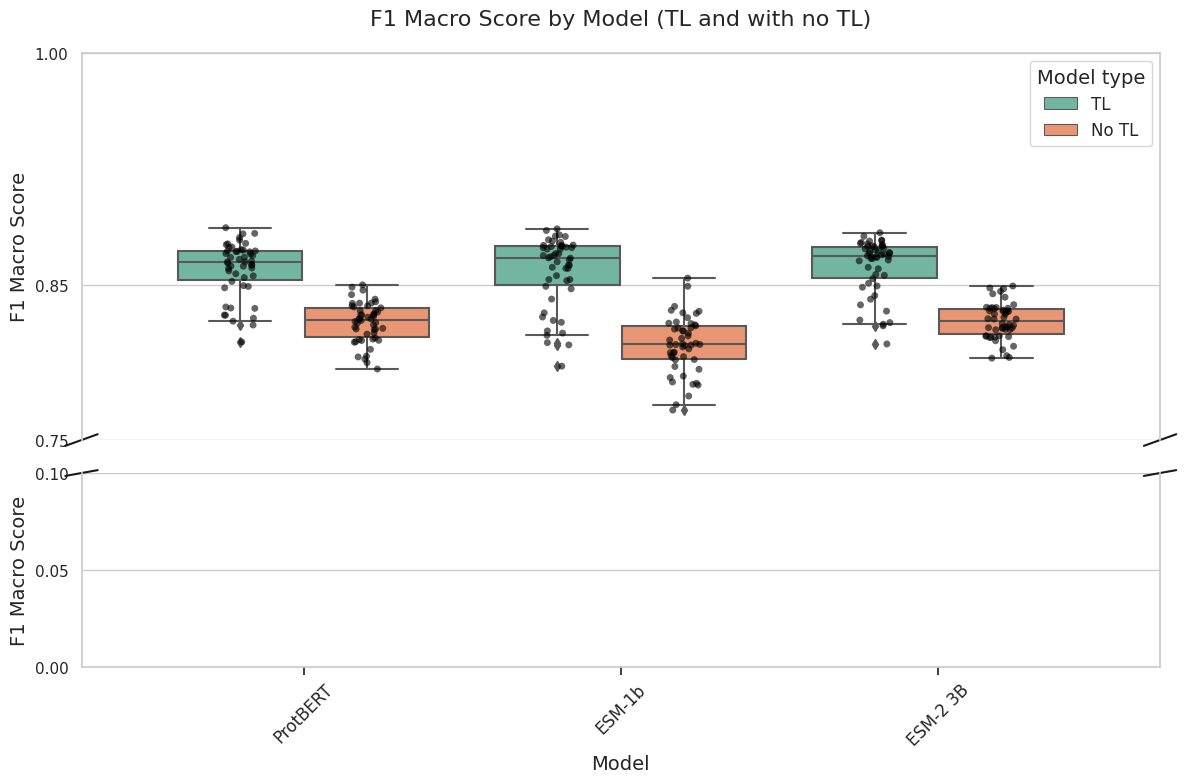

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style and color palette
sns.set(style="whitegrid")
palette = sns.color_palette("Set2")

# Create the figure with two subplots, sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8), gridspec_kw={'height_ratios': [2, 1]})

# First subplot: Upper part (0.75 to 1)
sns.boxplot(x='Model', y='F1_macro', hue='Model type', data=results_all, palette=palette, ax=ax1)
sns.stripplot(x='Model', y='F1_macro', hue='Model type', data=results_all, 
              palette=["black"], dodge=True, jitter=True, alpha=0.6, 
              edgecolor='gray', legend=False, ax=ax1)
ax1.set_ylim(0.75, 1)  # Limit y-axis to 0.75 to 1
ax1.set_yticks([0.75, 0.85, 1])

# Second subplot: Lower part (0 to 0.1)
sns.boxplot(x='Model', y='F1_macro', hue='Model type', data=results_all, palette=palette, ax=ax2)
sns.stripplot(x='Model', y='F1_macro', hue='Model type', data=results_all, 
              palette=["black"], dodge=True, jitter=True, alpha=0.6, 
              edgecolor='gray', legend=False, ax=ax2)
ax2.set_ylim(0, 0.1)  # Limit y-axis to 0 to 0.1
ax2.set_yticks([0, 0.05, 0.1])

# Adjust the appearance of the break
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't draw x-axis labels on the top plot
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the "break" in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Bottom-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Bottom-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Top-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Top-right diagonal

# Title and labels
ax1.set_title('F1 Macro Score by Model (TL and with no TL)', fontsize=16, pad=20)
ax2.set_xlabel('Model', fontsize=14)
ax1.set_ylabel('F1 Macro Score', fontsize=14)
ax2.set_ylabel('F1 Macro Score', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, fontsize=12)

# Adjust legend
ax1.legend(loc='upper right', title='Model type', fontsize=12, title_fontsize=14)
ax2.get_legend().remove()
ax1.get_xaxis().set_visible(False)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()


In [10]:
results

,Model type,Trial,Fold,F1_macro,Model
0,TF,11,0,0.823719,ESM-2 3B
1,No TF,11,0,0.823128,ESM-2 3B
2,TF,11,1,0.837254,ESM-2 3B
3,No TF,11,1,0.802885,ESM-2 3B
4,TF,11,2,0.856315,ESM-2 3B
...,...,...,...,...,...
95,No TF,20,2,0.844408,ESM-2 3B
96,TF,20,3,0.812025,ESM-2 3B
97,No TF,20,3,0.828120,ESM-2 3B
98,TF,20,4,0.868564,ESM-2 3B


In [12]:
# wilcoxon test
import scipy.stats as stats

# ProtBERT vs ESM-1b
stats.wilcoxon(results_all[(results_all["Model"] == "ProtBERT") & (results_all["Model type"] == "TL")]["F1_macro"],
               results_all[(results_all["Model"] == "ProtBERT") & (results_all["Model type"] == "No TL")]["F1_macro"])

WilcoxonResult(statistic=12.0, pvalue=1.5591448621045152e-09)

In [13]:
# wilcoxon test
import scipy.stats as stats

# ProtBERT vs ESM-1b
stats.wilcoxon(results_all[(results_all["Model"] == "ESM-1b") & (results_all["Model type"] == "TL")]["F1_macro"],
               results_all[(results_all["Model"] == "ESM-1b") & (results_all["Model type"] == "No TL")]["F1_macro"])

WilcoxonResult(statistic=12.0, pvalue=1.5591448621045152e-09)

In [14]:
# wilcoxon test
import scipy.stats as stats

# ProtBERT vs ESM-1b
stats.wilcoxon(results_all[(results_all["Model"] == "ESM-2 3B") & (results_all["Model type"] == "TL")]["F1_macro"],
               results_all[(results_all["Model"] == "ESM-2 3B") & (results_all["Model type"] == "No TL")]["F1_macro"])

WilcoxonResult(statistic=25.0, pvalue=3.366814035344517e-09)

In [15]:
# wilcoxon test
import scipy.stats as stats

# ProtBERT vs ESM-1b
stats.wilcoxon(results_all[(results_all["Model"] == "ProtBERT") & (results_all["Model type"] == "TL")]["F1_macro"],
               results_all[(results_all["Model"] == "ESM-2 3B") & (results_all["Model type"] == "TL")]["F1_macro"])

WilcoxonResult(statistic=605.0, pvalue=0.7537249310173678)

In [16]:
# wilcoxon test
import scipy.stats as stats

# ProtBERT vs ESM-1b
stats.wilcoxon(results_all[(results_all["Model"] == "ESM-1b") & (results_all["Model type"] == "TL")]["F1_macro"],
               results_all[(results_all["Model"] == "ESM-2 3B") & (results_all["Model type"] == "TL")]["F1_macro"])

WilcoxonResult(statistic=582.0, pvalue=0.592126527158545)

In [17]:
# wilcoxon test
import scipy.stats as stats

# ProtBERT vs ESM-1b
stats.wilcoxon(results_all[(results_all["Model"] == "ESM-1b") & (results_all["Model type"] == "TL")]["F1_macro"],
               results_all[(results_all["Model"] == "ProtBERT") & (results_all["Model type"] == "TL")]["F1_macro"])

WilcoxonResult(statistic=631.0, pvalue=0.9499685188719619)

In [30]:
import pandas as pd

optimization_results = pd.read_csv("../results_experiments/results_esm2_3b_trial_24.csv")
optimization_results.head()

,Unnamed: 0,fold,mf1,wf1,mrecall,wrecall,mprecision,wprecision,level_1_f1,level_2_f1,level_3_f1,level_4_f1,level_1_wf1,level_2_wf1,level_3_wf1,level_4_wf1,mf1_val
0,0,0,0.855302,0.958703,0.855707,0.953615,0.875861,0.967740,0.973853,0.924924,0.915906,0.825106,0.979274,0.971030,0.956887,0.908716,0.841211
1,0,1,0.867183,0.959358,0.865292,0.953816,0.893193,0.969300,0.973722,0.931569,0.914799,0.842054,0.979526,0.969490,0.958961,0.912688,0.854531
2,0,2,0.873722,0.959209,0.876588,0.953178,0.891979,0.969679,0.969398,0.927495,0.912918,0.852815,0.980762,0.970394,0.955484,0.914275,0.856720
3,0,3,0.861179,0.959178,0.862687,0.953897,0.880839,0.968530,0.980061,0.933439,0.887904,0.841689,0.980773,0.972025,0.954883,0.911830,0.845853
4,0,4,0.859888,0.960116,0.862534,0.955089,0.879462,0.968848,0.976133,0.924445,0.914785,0.832211,0.980081,0.973761,0.960538,0.906835,0.855399


In [31]:
blast_results = pd.read_csv("../results_experiments/blast_results_plants.csv")
blast_results

,fold,mf1,wf1,mrecall,wrecall,mprecision,wprecision,level_1_f1,level_2_f1,level_3_f1,level_4_f1,level_1_wf1,level_2_wf1,level_3_wf1,level_4_wf1
0,0,0.886559,0.960750,0.895570,0.948256,0.899705,0.977017,0.973211,0.945205,0.923078,0.866068,0.974415,0.969774,0.958991,0.927064
1,1,0.895264,0.960550,0.896873,0.946105,0.915976,0.979139,0.963240,0.926799,0.908849,0.885876,0.971360,0.966818,0.958962,0.936313
2,2,0.901485,0.964483,0.904280,0.951521,0.916616,0.981396,0.968706,0.941911,0.923371,0.888312,0.976846,0.971406,0.962353,0.937915
3,3,0.888475,0.958519,0.897872,0.944799,0.900862,0.976647,0.968727,0.928143,0.903419,0.877448,0.971219,0.965823,0.957418,0.928885
4,4,0.890272,0.960492,0.894592,0.947091,0.905485,0.977711,0.969693,0.917717,0.920767,0.875696,0.972515,0.967520,0.958438,0.933784


In [32]:
import pandas as pd

esm1b_results = pd.read_csv("../results_experiments/results_esm1b_trial_23.csv")
esm1b_results.head()

,Unnamed: 0,fold,mf1,wf1,mrecall,wrecall,mprecision,wprecision,level_1_f1,level_2_f1,level_3_f1,level_4_f1,level_1_wf1,level_2_wf1,level_3_wf1,level_4_wf1,mf1_val
0,0,0,0.868446,0.962545,0.873428,0.959150,0.885265,0.969532,0.976080,0.940340,0.918501,0.841582,0.981459,0.971102,0.961191,0.920540,0.858970
1,0,1,0.844750,0.951156,0.851996,0.947069,0.864690,0.960110,0.961787,0.914718,0.881879,0.822183,0.974406,0.962163,0.947510,0.903242,0.838908
2,0,2,0.887236,0.964749,0.890543,0.961113,0.901580,0.971466,0.974176,0.940849,0.919461,0.868759,0.983160,0.973817,0.962861,0.925165,0.876798
3,0,3,0.833278,0.951217,0.848678,0.949523,0.848269,0.958459,0.973167,0.921403,0.880398,0.804859,0.977171,0.963977,0.950794,0.891246,0.826881
4,0,4,0.808526,0.947905,0.826982,0.947179,0.821766,0.954444,0.966123,0.908293,0.874825,0.772144,0.973922,0.964841,0.947776,0.880827,0.792789


In [33]:
import pandas as pd

protbert_results = pd.read_csv("../results_experiments/results_protbert_trial_48.csv")
protbert_results.head()

,Unnamed: 0,fold,mf1,wf1,mrecall,wrecall,mprecision,wprecision,level_1_f1,level_2_f1,level_3_f1,level_4_f1,level_1_wf1,level_2_wf1,level_3_wf1,level_4_wf1,mf1_val
0,0,0,0.870030,0.958610,0.861387,0.949837,0.898399,0.971432,0.971613,0.941713,0.920872,0.843032,0.978222,0.969065,0.954943,0.916050,0.851879
1,0,1,0.867621,0.956842,0.862537,0.948909,0.892139,0.968527,0.965624,0.927313,0.901275,0.847754,0.975902,0.964320,0.955294,0.917788,0.863509
2,0,2,0.879222,0.958615,0.873033,0.949778,0.905130,0.971468,0.968910,0.928308,0.903788,0.863752,0.979525,0.965917,0.955470,0.919800,0.863497
3,0,3,0.869684,0.957533,0.864270,0.948386,0.895070,0.970826,0.974484,0.925949,0.889905,0.854506,0.977246,0.965986,0.955198,0.917003,0.860399
4,0,4,0.866489,0.960928,0.860718,0.954561,0.893395,0.970991,0.978510,0.922702,0.901807,0.846283,0.983144,0.970234,0.958368,0.915461,0.862616


In [34]:
esm2_results = pd.read_csv("../results_experiments/results_esm2_3b_trial_24.csv")
esm2_results

,Unnamed: 0,fold,mf1,wf1,mrecall,wrecall,mprecision,wprecision,level_1_f1,level_2_f1,level_3_f1,level_4_f1,level_1_wf1,level_2_wf1,level_3_wf1,level_4_wf1,mf1_val
0,0,0,0.855302,0.958703,0.855707,0.953615,0.875861,0.967740,0.973853,0.924924,0.915906,0.825106,0.979274,0.971030,0.956887,0.908716,0.841211
1,0,1,0.867183,0.959358,0.865292,0.953816,0.893193,0.969300,0.973722,0.931569,0.914799,0.842054,0.979526,0.969490,0.958961,0.912688,0.854531
2,0,2,0.873722,0.959209,0.876588,0.953178,0.891979,0.969679,0.969398,0.927495,0.912918,0.852815,0.980762,0.970394,0.955484,0.914275,0.856720
3,0,3,0.861179,0.959178,0.862687,0.953897,0.880839,0.968530,0.980061,0.933439,0.887904,0.841689,0.980773,0.972025,0.954883,0.911830,0.845853
4,0,4,0.859888,0.960116,0.862534,0.955089,0.879462,0.968848,0.976133,0.924445,0.914785,0.832211,0.980081,0.973761,0.960538,0.906835,0.855399


In [35]:
esm2_results.drop(columns=["Unnamed: 0", "mf1_val"], inplace=True)
esm1b_results.drop(columns=["Unnamed: 0", "mf1_val"], inplace=True)
protbert_results.drop(columns=["Unnamed: 0", "mf1_val"], inplace=True)

In [36]:
esm2_results["Method"] = "ESM-2 3B"
blast_results["Method"] = "BLASTp"
esm1b_results["Method"] = "ESM1b"
protbert_results["Method"] = "ProtBERT"
results = pd.concat([esm2_results, blast_results, esm1b_results, protbert_results])

In [37]:
results_ = results.loc[:, ["Method", "fold", "level_1_wf1", "level_2_wf1", "level_3_wf1", "level_4_wf1"]]

In [38]:
general_purpose = pd.read_csv("../results_experiments/esm2_3b_general_no_plants_results.csv")

In [39]:
general_purpose["Method"] = "ESM2-3B (General purpose)"

In [40]:

general_purpose = general_purpose.loc[:, ["Method", "fold", "level_1_wf1", "level_2_wf1", "level_3_wf1", "level_4_wf1"]]

In [41]:
results_ = pd.concat([results_, general_purpose])
results_.columns = ["Method", "Fold", "Level 1", "Level 2", "Level 3", "Level 4"]

/tmp/ipykernel_1699399/3961126136.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(sorted_means.index, rotation=90)
/tmp/ipykernel_1699399/3961126136.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(sorted_means.index, rotation=90)
/tmp/ipykernel_1699399/3961126136.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(sorted_means.index, rotation=90)
/tmp/ipykernel_1699399/3961126136.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(sorted_means.index, rotation=90)


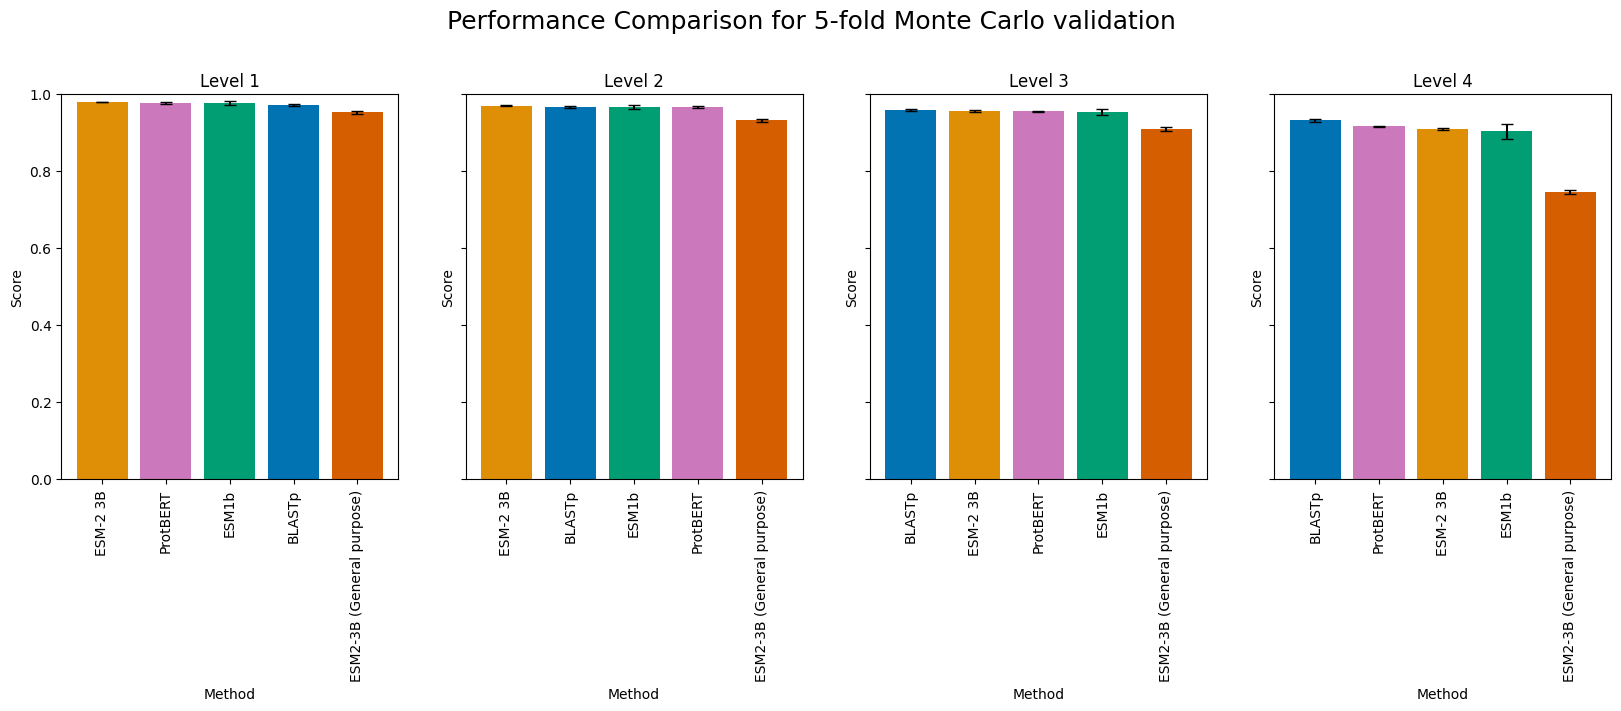

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `results_` is your DataFrame
df = results_

# Extracting columns related to the levels
level_columns = [col for col in df.columns if 'Level' in col]

# Calculating means and standard deviations
means = df.groupby('Method')[level_columns].mean()
stds = df.groupby('Method')[level_columns].std()

# Create a colorblind-friendly color palette
palette = sns.color_palette("colorblind", len(means.index))

# Map each method to a specific color
color_map = {method: palette[i] for i, method in enumerate(means.index)}

# Preparing the plot
fig, axes = plt.subplots(nrows=1, ncols=len(level_columns), figsize=(20, 5), sharey=True)

for ax, level in zip(axes, level_columns):
    # Sort the means and stds by the mean values for this level
    sorted_means = means[level].sort_values(ascending=False)
    sorted_stds = stds[level].loc[sorted_means.index]
    
    # Get the color for each bar
    colors = [color_map[method] for method in sorted_means.index]
    
    # Plot the bars with error bars
    ax.bar(sorted_means.index, sorted_means, yerr=sorted_stds, capsize=4, color=colors)
    ax.set_xticklabels(sorted_means.index, rotation=90)
    ax.set_title(level)
    ax.set_xlabel('Method')
    ax.set_ylabel('Score')
    ax.set_ylim(0.0, 1)  # Adjust y-axis to better visualize error bars

# Set a main title for the figure
fig.suptitle('Performance Comparison for 5-fold Monte Carlo validation', fontsize=18, y=1.05)

# Display the plot
plt.show()

# Include general purpose models

In [34]:
import pandas as pd

dataset = pd.read_csv("/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/general_purpose_pipeline/ec_number_prediction/embeddings/merged_dataset_no_plants.csv", nrows=5)

In [35]:
labels = dataset.columns[8:]
labels = list(labels)

In [36]:
from plants_sm.models.lightning_model import InternalLightningModel
from ec_number_prediction.transfer_learning.models import ModelECNumber
from plants_sm.io.pickle import read_pickle
import os
from plants_sm.models.constants import BINARY, FileConstants

path = "/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/general_purpose_pipeline/ec_number_prediction/model_esm2_3b_no_plants/"
module = ModelECNumber(input_dim=1024, layers=[2560], classification_neurons=5405,learning_rate=0.0001)
# module.load_from_checkpoint("/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/general_purpose_pipeline/ec_number_prediction/model_esm2_3b_no_plants/pytorch_model_weights.ckpt")
weights_path = os.path.join(path, "pytorch_model_weights.ckpt")
model = read_pickle(os.path.join(path, FileConstants.PYTORCH_MODEL_PKL.value))
model_parameters = read_pickle(os.path.join(path, FileConstants.MODEL_PARAMETERS_PKL.value))
model = model.load_from_checkpoint(weights_path,input_dim=2560, layers=[2560], classification_neurons=5405,learning_rate=0.0001)
model = InternalLightningModel(module=model)
model

/home/jcapela/.local/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


TypeError: _update_constructor_parameters() takes 0 positional arguments but 1 was given

In [ ]:
base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"
test_datasets_path = os.path.join(base_path_data, "plants/test_datasets/")
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
import re

def get_ec_levels(labels):
    level_1 = []
    level_2 = []
    level_3 = []
    level_4 = []
    for i, label in enumerate(labels):
        if re.match(r"^\d+.\d+.\d+.n*\d+$", label):
            level_4.append(i)
        elif re.match(r"^\d+.\d+.\d+$", label):
            level_3.append(i)
        elif re.match(r"^\d+.\d+$", label):
            level_2.append(i)
        elif re.match(r"^\d+$", label):
            level_1.append(i)
    return level_1, level_2, level_3, level_4

predictions_folds = []
results_dataframe = pd.DataFrame()
for i in range(5):
    print(f"Loading dataset {i}")
    test_dataset_true = pd.read_csv(test_datasets_path + f"test_dataset_{i}.csv").iloc[:, 11:]
    test_dataset = SingleInputDataset.from_csv(test_datasets_path + f"test_dataset_{i}.csv", representation_field="sequence", instances_ids_field="accession",
                                                labels_field=slice(11,-1))

    labels_to_consider = list(test_dataset_true.columns)
    labels_to_consider_ = []
    for label in labels_to_consider:
        if label in labels:
            labels_to_consider_.append(label)
    

    test_dataset.load_features(os.path.join(base_path_data, "swiss_prot_ec_plants_esm/"))
    predictions = model.predict(test_dataset)
    y_pred = pd.DataFrame(predictions, columns=labels).loc[:, labels_to_consider_]
    y_true = test_dataset_true.loc[:, labels_to_consider_]
    from sklearn.metrics import f1_score, precision_score, recall_score


    mf1 = f1_score(y_true, y_pred, average='macro')
    wf1 = f1_score(y_true, y_pred, average='weighted')
    mrecall = recall_score(y_true, y_pred, average='macro')
    wrecall = recall_score(y_true, y_pred, average='weighted')
    mprecision = precision_score(y_true, y_pred, average='macro')
    wprecision = precision_score(y_true, y_pred, average='weighted')

    level_1, level_2, level_3, level_4 = get_ec_levels(y_pred.columns)

    level_1_f1 = f1_score(y_true.iloc[:, level_1], y_pred.iloc[:, level_1], average='macro')
    level_2_f1 = f1_score(y_true.iloc[:, level_2], y_pred.iloc[:, level_2], average='macro')
    level_3_f1 = f1_score(y_true.iloc[:, level_3], y_pred.iloc[:, level_3], average='macro')
    level_4_f1 = f1_score(y_true.iloc[:, level_4], y_pred.iloc[:, level_4], average='macro')

    level_1_wf1 = f1_score(y_true.iloc[:, level_1], y_pred.iloc[:, level_1], average='weighted')
    level_2_wf1 = f1_score(y_true.iloc[:, level_2], y_pred.iloc[:, level_2], average='weighted')
    level_3_wf1 = f1_score(y_true.iloc[:, level_3], y_pred.iloc[:, level_3], average='weighted')
    level_4_wf1 = f1_score(y_true.iloc[:, level_4], y_pred.iloc[:, level_4], average='weighted')

    results_dataframe_i = pd.DataFrame({"fold": [i], "mf1": [mf1], "wf1": [wf1], "mrecall": [mrecall], "wrecall": [wrecall], "mprecision": [mprecision], "wprecision": [wprecision],
                                        "level_1_f1": [level_1_f1], "level_2_f1": [level_2_f1], "level_3_f1": [level_3_f1], "level_4_f1": [level_4_f1],
                                        "level_1_wf1": [level_1_wf1], "level_2_wf1": [level_2_wf1], "level_3_wf1": [level_3_wf1], "level_4_wf1": [level_4_wf1]})
    results_dataframe = results_dataframe.append(results_dataframe_i)
    
    predictions_folds.append(predictions)
results_dataframe.to_csv("/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/esm2_3b_general_no_plants_results.csv", index=False)


In [7]:
import os
import pandas as pd

base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"
test_datasets_path = os.path.join(base_path_data, "plants_sm/test_datasets/")
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
import re

def get_ec_levels(labels):
    level_1 = []
    level_2 = []
    level_3 = []
    level_4 = []
    for i, label in enumerate(labels):
        if re.match(r"^\d+.\d+.\d+.n*\d+$", label):
            level_4.append(i)
        elif re.match(r"^\d+.\d+.\d+$", label):
            level_3.append(i)
        elif re.match(r"^\d+.\d+$", label):
            level_2.append(i)
        elif re.match(r"^\d+$", label):
            level_1.append(i)
    return level_1, level_2, level_3, level_4

predictions_folds = []
results_dataframe = pd.DataFrame()
for i in range(5):
    print(f"Loading dataset {i}")
    test_dataset_true = pd.read_csv(test_datasets_path + f"test_dataset_{i}.csv").iloc[:, 11:]
    test_dataset = SingleInputDataset.from_csv(test_datasets_path + f"test_dataset_{i}.csv", representation_field="sequence", instances_ids_field="accession",
                                                labels_field=slice(11,-1))

    labels_to_consider = list(test_dataset_true.columns)
    labels_to_consider_ = []
    for label in labels_to_consider:
        if label in labels:
            labels_to_consider_.append(label)
    

    test_dataset.load_features(os.path.join(base_path_data, "swiss_prot_ec_plants_esm/"))
    predictions = model.predict(test_dataset)
    y_pred = pd.DataFrame(predictions, columns=labels).loc[:, labels_to_consider_]
    y_true = test_dataset_true.loc[:, labels_to_consider_]
    from sklearn.metrics import f1_score, precision_score, recall_score


    mf1 = f1_score(y_true, y_pred, average='macro')
    wf1 = f1_score(y_true, y_pred, average='weighted')
    mrecall = recall_score(y_true, y_pred, average='macro')
    wrecall = recall_score(y_true, y_pred, average='weighted')
    mprecision = precision_score(y_true, y_pred, average='macro')
    wprecision = precision_score(y_true, y_pred, average='weighted')

    level_1, level_2, level_3, level_4 = get_ec_levels(y_pred.columns)

    level_1_f1 = f1_score(y_true.iloc[:, level_1], y_pred.iloc[:, level_1], average='macro')
    level_2_f1 = f1_score(y_true.iloc[:, level_2], y_pred.iloc[:, level_2], average='macro')
    level_3_f1 = f1_score(y_true.iloc[:, level_3], y_pred.iloc[:, level_3], average='macro')
    level_4_f1 = f1_score(y_true.iloc[:, level_4], y_pred.iloc[:, level_4], average='macro')

    level_1_wf1 = f1_score(y_true.iloc[:, level_1], y_pred.iloc[:, level_1], average='weighted')
    level_2_wf1 = f1_score(y_true.iloc[:, level_2], y_pred.iloc[:, level_2], average='weighted')
    level_3_wf1 = f1_score(y_true.iloc[:, level_3], y_pred.iloc[:, level_3], average='weighted')
    level_4_wf1 = f1_score(y_true.iloc[:, level_4], y_pred.iloc[:, level_4], average='weighted')

    results_dataframe_i = pd.DataFrame({"fold": [i], "mf1": [mf1], "wf1": [wf1], "mrecall": [mrecall], "wrecall": [wrecall], "mprecision": [mprecision], "wprecision": [wprecision],
                                        "level_1_f1": [level_1_f1], "level_2_f1": [level_2_f1], "level_3_f1": [level_3_f1], "level_4_f1": [level_4_f1],
                                        "level_1_wf1": [level_1_wf1], "level_2_wf1": [level_2_wf1], "level_3_wf1": [level_3_wf1], "level_4_wf1": [level_4_wf1]})
    results_dataframe = results_dataframe.append(results_dataframe_i)
    
    predictions_folds.append(predictions)
results_dataframe.to_csv("/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/esm2_3b_general_no_plants_results_SM.csv", index=False)


Loading dataset 0


2024-07-23 14:56:01.191310: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-23 14:56:01.709955: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-07-23 14:56:02.603008: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-23 14:56:02.603052: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-23 14:56:02.603083: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

Predicting DataLoader 0: 100%|██████████| 11/11 [00:00<00:00, 75.79it/s]


/home/jcapela/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/jcapela/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/tmp/ipykernel_2890944/678300617.py:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_dataframe = results_dataframe.append(results_dataframe_i)
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not 

Loading dataset 1
Predicting DataLoader 0: 100%|██████████| 11/11 [00:00<00:00, 130.25it/s]
Loading dataset 2


...

Predicting DataLoader 0: 100%|██████████| 11/11 [00:00<00:00, 143.13it/s]
Loading dataset 4


/home/jcapela/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/jcapela/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/tmp/ipykernel_2890944/678300617.py:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_dataframe = results_dataframe.append(results_dataframe_i)
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not 

Predicting DataLoader 0: 100%|██████████| 11/11 [00:00<00:00, 141.14it/s]

/home/jcapela/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/jcapela/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


/tmp/ipykernel_2890944/678300617.py:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_dataframe = results_dataframe.append(results_dataframe_i)


In [37]:
import pandas as pd

results = pd.read_csv("../results_experiments/results_esm2_3b_plants_sm.csv")
results.head()

,Model type,Trial,Fold,F1_macro
0,TL (general purpose model),27,0,0.876414
1,No TL (general purpose model),27,0,0.849228
2,TL (plant-specific model),27,0,0.833136
3,No TL (plant-specific model),27,0,0.801448
4,TL (general purpose model),27,1,0.875209


In [38]:
results["Model"] = "ESM-2 3B"

In [39]:
results_other = pd.read_csv("../results_experiments/results_esm1b_plants_sm.csv")
results_other["Model"] = "ESM1b"

results = pd.concat([results, results_other])
results_other = pd.read_csv("../results_experiments/results_protbert_plants_sm.csv")
results_other["Model"] = "ProtBERT"

results = pd.concat([results, results_other])

/tmp/ipykernel_4094470/3230556535.py:13: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(x='Model', y='F1_macro', hue='Model type', data=results,
/tmp/ipykernel_4094470/3230556535.py:21: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(x='Model', y='F1_macro', hue='Model type', data=results,


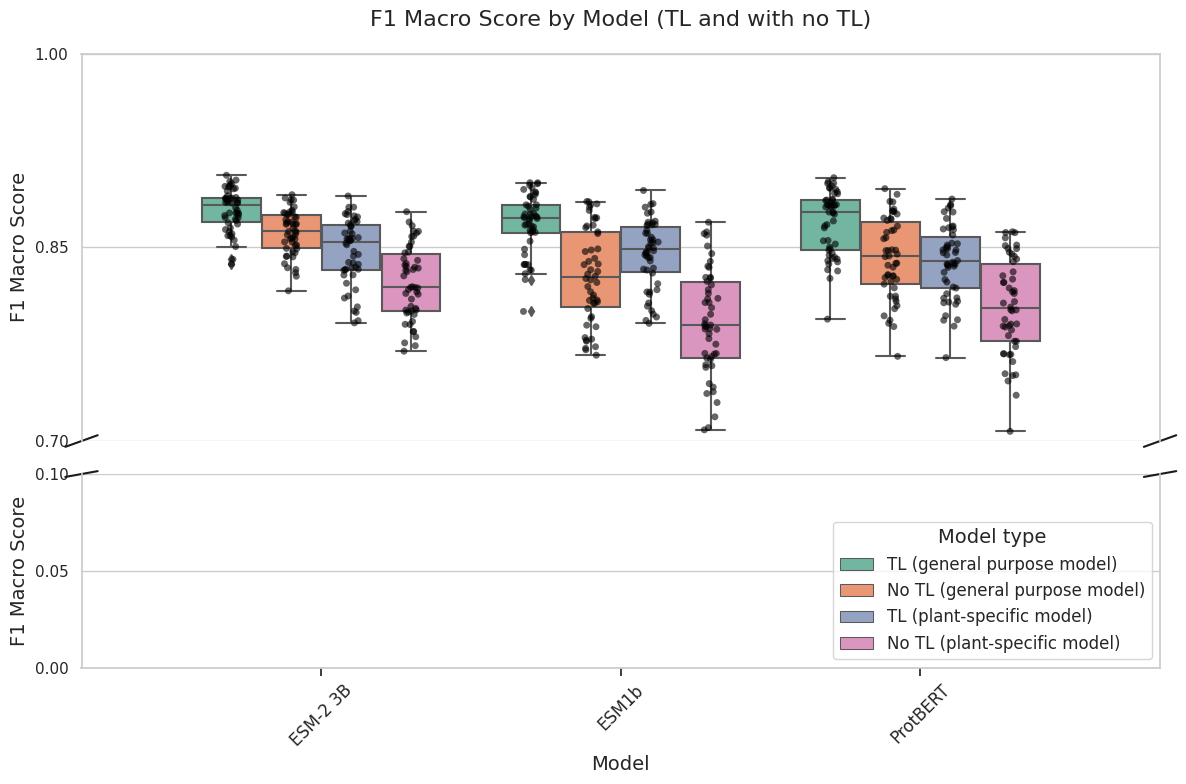

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style and color palette
sns.set(style="whitegrid")
palette = sns.color_palette("Set2")

# Create the figure with two subplots, sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8), gridspec_kw={'height_ratios': [2, 1]})

# First subplot: Upper part (0.75 to 1)
sns.boxplot(x='Model', y='F1_macro', hue='Model type', data=results, palette=palette, ax=ax1)
sns.stripplot(x='Model', y='F1_macro', hue='Model type', data=results, 
              palette=["black"], dodge=True, jitter=True, alpha=0.6, 
              edgecolor='gray', legend=False, ax=ax1)
ax1.set_ylim(0.75, 1)  # Limit y-axis to 0.75 to 1
ax1.set_yticks([0.70, 0.85, 1])

# Second subplot: Lower part (0 to 0.1)
sns.boxplot(x='Model', y='F1_macro', hue='Model type', data=results, palette=palette, ax=ax2)
sns.stripplot(x='Model', y='F1_macro', hue='Model type', data=results, 
              palette=["black"], dodge=True, jitter=True, alpha=0.6, 
              edgecolor='gray', legend=False, ax=ax2)
ax2.set_ylim(0, 0.1)  # Limit y-axis to 0 to 0.1
ax2.set_yticks([0, 0.05, 0.1])

# Adjust the appearance of the break
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't draw x-axis labels on the top plot
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the "break" in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Bottom-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Bottom-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Top-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Top-right diagonal

# Title and labels
ax1.set_title('F1 Macro Score by Model (TL and with no TL)', fontsize=16, pad=20)
ax2.set_xlabel('Model', fontsize=14)
ax1.set_ylabel('F1 Macro Score', fontsize=14)
ax2.set_ylabel('F1 Macro Score', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, fontsize=12)

# Adjust legend
ax2.legend(loc='lower right', title='Model type', fontsize=12, title_fontsize=14)
ax1.get_legend().remove()
ax1.get_xaxis().set_visible(False)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()


In [209]:
# wilcoxon test
import scipy.stats as stats

# ESM-2 3B
stats.wilcoxon(results[(results["Model"] == "ESM-2 3B") & (results["Model type"] == "TL (general purpose model)")]["F1_macro"],
               results[(results["Model"] == "ESM-2 3B") & (results["Model type"] == "No TL (general purpose model)")]["F1_macro"])

WilcoxonResult(statistic=81.0, pvalue=7.784669528923821e-08)

In [41]:
import pandas as pd
import scipy.stats as stats

def perform_wilcoxon_test(df):
    # Ensure the DataFrame has the necessary columns
    if not all(col in df.columns for col in ['Model', 'Model type', 'F1_macro']):
        raise ValueError("DataFrame must contain 'Model', 'Model type', and 'F1_macro' columns")

    # Get unique models and model types
    models = df['Model'].unique()
    model_types = df['Model type'].unique()
    
    # Store results
    results = []

    # Loop through each model
    for model in models:
        # Loop through each pair of model types
        for type1 in model_types:
            for type2 in model_types:
                if type1 < type2:  # To avoid redundant comparisons
                    # Filter the data for the current model and model types
                    data1 = df[(df['Model'] == model) & (df['Model type'] == type1)]['F1_macro']
                    data2 = df[(df['Model'] == model) & (df['Model type'] == type2)]['F1_macro']
                    
                    # Check if both datasets are non-empty and have the same length
                    if len(data1) == len(data2) and len(data1) > 0:
                        # Perform Wilcoxon signed-rank test
                        stat, p_value = stats.wilcoxon(data1, data2)
                        
                        # Store the results
                        results.append({
                            'Model': model,
                            'Type 1': type1,
                            'Type 2': type2,
                            'Statistic': stat,
                            'P-Value': p_value
                        })
                    else:
                        results.append({
                            'Model': model,
                            'Type 1': type1,
                            'Type 2': type2,
                            'Statistic': None,
                            'P-Value': None,
                            'Note': 'Data sizes do not match or are empty'
                        })
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

# Usage
results_df = perform_wilcoxon_test(results)

In [42]:
results_df

,Model,Type 1,Type 2,Statistic,P-Value
0,ESM-2 3B,TL (general purpose model),TL (plant-specific model),8.0,1.226512e-09
1,ESM-2 3B,No TL (general purpose model),TL (general purpose model),81.0,7.784670e-08
2,ESM-2 3B,No TL (general purpose model),TL (plant-specific model),260.0,2.683158e-04
3,ESM-2 3B,No TL (general purpose model),No TL (plant-specific model),25.0,3.366814e-09
4,ESM-2 3B,No TL (plant-specific model),TL (general purpose model),0.0,7.556929e-10
5,ESM-2 3B,No TL (plant-specific model),TL (plant-specific model),98.0,1.909447e-07
6,ESM1b,TL (general purpose model),TL (plant-specific model),56.0,1.984104e-08
7,ESM1b,No TL (general purpose model),TL (general purpose model),47.0,1.196241e-08
8,ESM1b,No TL (general purpose model),TL (plant-specific model),377.0,1.191408e-02
9,ESM1b,No TL (general purpose model),No TL (plant-specific model),42.0,9.002403e-09


In [43]:
# wilcoxon test
import scipy.stats as stats

# ESM-2 3B
stats.wilcoxon(results[(results["Model"] == "ESM-2 3B") & (results["Model type"] == "TL (plant-specific model)")]["F1_macro"],
               results[(results["Model"] == "ESM-2 3B") & (results["Model type"] == "No TL (plant-specific model)")]["F1_macro"])

WilcoxonResult(statistic=98.0, pvalue=1.9094468838628967e-07)

In [49]:
import pandas as pd

esm2_results = pd.read_csv("../results_experiments/results_esm2_3b_trial_9_plants_sm.csv")
esm2_results

esm1b_results = pd.read_csv("../results_experiments/results_esm1b_trial_35_plants_sm.csv")
esm1b_results

protbert_results = pd.read_csv("../results_experiments/results_protbert_trial_24_plants_sm.csv")
protbert_results

,Unnamed: 0,fold,mf1,wf1,mrecall,wrecall,mprecision,wprecision,level_1_f1,level_2_f1,level_3_f1,level_4_f1,level_1_wf1,level_2_wf1,level_3_wf1,level_4_wf1,mf1_val
0,0,0,0.887746,0.953903,0.895891,0.953264,0.904996,0.961900,0.962054,0.962298,0.906984,0.858130,0.975122,0.972450,0.960891,0.906039,NaN
1,0,1,0.898444,0.958308,0.909124,0.962182,0.905550,0.960730,0.958096,0.942157,0.912749,0.879083,0.975286,0.971381,0.960679,0.923259,NaN
2,0,2,0.886038,0.957177,0.894318,0.955492,0.903900,0.966598,0.984755,0.953061,0.926716,0.849074,0.985812,0.979493,0.968367,0.891990,NaN
3,0,3,0.894541,0.959239,0.888058,0.948023,0.925172,0.979476,0.975337,0.957059,0.900826,0.872301,0.980701,0.973521,0.963608,0.917545,NaN
4,0,4,0.850608,0.947397,0.873906,0.947666,0.852219,0.955436,0.962846,0.945850,0.887666,0.807239,0.977806,0.971678,0.965885,0.871285,NaN


In [50]:
blast_results = pd.read_csv("../results_experiments/blast_results_plants_sm.csv")

In [51]:
general_model_results = pd.read_csv("../results_experiments/esm2_3b_general_no_plants_results_SM.csv")
general_model_results

,fold,mf1,wf1,mrecall,wrecall,mprecision,wprecision,level_1_f1,level_2_f1,level_3_f1,level_4_f1,level_1_wf1,level_2_wf1,level_3_wf1,level_4_wf1
0,0,0.633165,0.843783,0.646173,0.830458,0.653415,0.876795,0.939552,0.884771,0.814408,0.472747,0.953019,0.924460,0.899188,0.580507
1,1,0.651555,0.859846,0.658843,0.845081,0.686598,0.904356,0.925624,0.873689,0.854065,0.492541,0.949884,0.929838,0.917409,0.615441
2,2,0.670592,0.869621,0.675629,0.860044,0.699458,0.897959,0.956335,0.922040,0.849744,0.512313,0.964080,0.939749,0.926454,0.627277
3,3,0.664176,0.865931,0.672775,0.857883,0.696460,0.904734,0.931497,0.926278,0.841312,0.504922,0.952036,0.944089,0.918751,0.629815
4,4,0.665577,0.866754,0.669902,0.858268,0.699948,0.905427,0.956622,0.928377,0.857825,0.498589,0.966917,0.946503,0.934393,0.595798


In [52]:
esm2_results.drop(columns=["Unnamed: 0", "mf1_val"], inplace=True)
esm1b_results.drop(columns=["Unnamed: 0", "mf1_val"], inplace=True)
protbert_results.drop(columns=["Unnamed: 0", "mf1_val"], inplace=True)

esm2_results["Method"] = "ESM-2 3B"
esm1b_results["Method"] = "ESM1b"
protbert_results["Method"] = "ProtBERT"
blast_results["Method"] = "BLASTp"
general_model_results["Method"] = "ESM2-3B (General purpose)"
results = pd.concat([esm2_results, blast_results, esm1b_results, protbert_results,general_model_results])
results = results.loc[:, ["Method", "fold", "level_1_wf1", "level_2_wf1", "level_3_wf1", "level_4_wf1"]]
results.columns = ["Method", "Fold", "Level 1", "Level 2", "Level 3", "Level 4"]

/tmp/ipykernel_1699399/228004153.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(sorted_means.index, rotation=90)
/tmp/ipykernel_1699399/228004153.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(sorted_means.index, rotation=90)
/tmp/ipykernel_1699399/228004153.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(sorted_means.index, rotation=90)
/tmp/ipykernel_1699399/228004153.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(sorted_means.index, rotation=90)


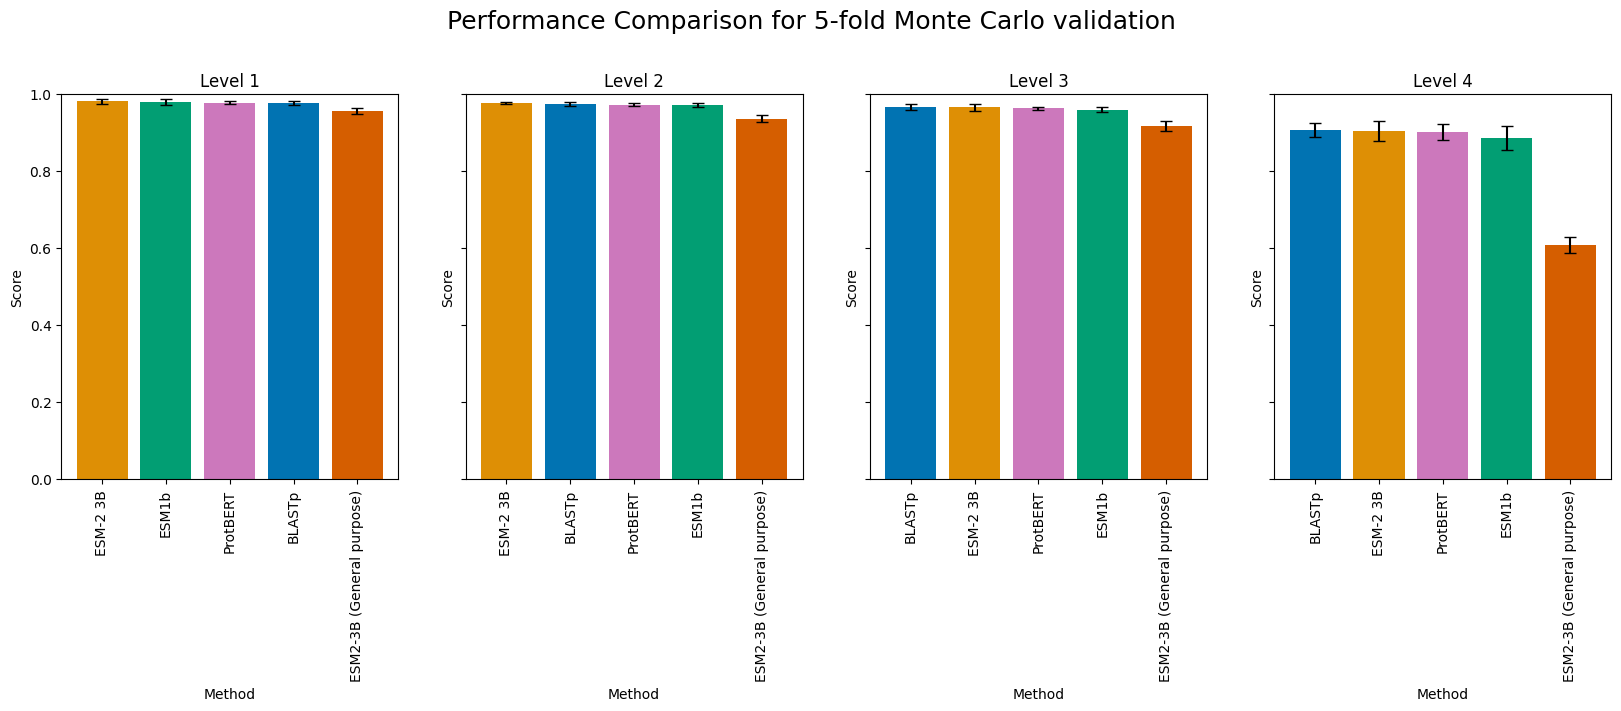

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `results_` is your DataFrame
df = results

# Extracting columns related to the levels
level_columns = [col for col in df.columns if 'Level' in col]

# Calculating means and standard deviations
means = df.groupby('Method')[level_columns].mean()
stds = df.groupby('Method')[level_columns].std()

# Create a colorblind-friendly color palette
palette = sns.color_palette("colorblind", len(means.index))

# Preparing the plot
fig, axes = plt.subplots(nrows=1, ncols=len(level_columns), figsize=(20, 5), sharey=True)

for ax, level in zip(axes, level_columns):
    # Sort the means and stds by the mean values for this level
    sorted_means = means[level].sort_values(ascending=False)
    sorted_stds = stds[level].loc[sorted_means.index]
    
    # Get the color for each bar
    colors = [color_map[method] for method in sorted_means.index]
    
    # Plot the bars with error bars
    ax.bar(sorted_means.index, sorted_means, yerr=sorted_stds, capsize=4, color=colors)
    ax.set_xticklabels(sorted_means.index, rotation=90)
    ax.set_title(level)
    ax.set_xlabel('Method')
    ax.set_ylabel('Score')
    ax.set_ylim(0.0, 1)  # Adjust y-axis to better visualize error bars

# Set a main title for the figure
fig.suptitle('Performance Comparison for 5-fold Monte Carlo validation', fontsize=18, y=1.05)

# Display the plot
plt.show()